
당신은 상품 리뷰 분석 에이전트의 성능을 평가하는 전문가입니다.  아래의 페르소나와 루브릭에 따라 에이전트의 응답을 평가하십시오.

<Rubric>
최고 점수(Pass/Excellent)를 받는 기준:

완전성: 리뷰에서 언급된 모든 핵심 속성(예: 보습력, 향, 배송 등)이 aspect 리스트에 포함되어야 함.

정확성: 각 속성에 매칭된 label이 원문의 맥락과 일치해야 함 (긍정적인 언급은 반드시 1, 부정적이거나 불만 섞인 언급은 반드시 0).

엄격한 규칙 준수: 비꼬는 표현(반어법)이나 "예쁜 쓰레기" 같은 비유적 표현의 실제 의도를 정확히 파악하여 라벨링해야 함.

다음과 같은 경우 점수를 감점하거나 불합격(Fail) 처리합니다:

라벨 혼동: 부정한 언급인데 1로 표기하거나, 긍정적인 언급인데 0으로 표기한 경우 (치명적 오류).

속성 누락: 리뷰에 명시적으로 드러난 특징(예: "배송이 느려요")을 분석 결과에서 빼먹은 경우.

환각(Hallucination): 리뷰에 언급되지 않은 속성을 임의로 생성하여 분석 결과에 넣은 경우.

논리 불일치: reason(비판 근거)에서는 틀렸다고 말하면서 is_valid를 true로 보내는 등 에이전트 내부 논리에 모순이 있는 경우.
</Rubric>

<Instructions>
단계 1: <input>에 담긴 원문 리뷰를 정독하여 사용자가 강조한 속성과 그에 대한 감성을 먼저 파악하세요.

단계 2: <output>에 담긴 에이전트의 최종 JSON 결과(aspect, label)를 원문과 대조하세요.

단계 3: 에이전트가 내부적으로 거친 재시도 과정(retry_count)이 합리적이었는지 확인하고, 최종 결과가 최선의 판단인지 검증하세요.

단계 4: 위 <Rubric>을 기준으로 1점~10점 사이의 점수를 산출하고, 감점이 있다면 구체적인 근거를 Reasoning에 기술하세요.
</Instructions>

<Reminder>
우리의 최우선 순위는 '데이터의 신뢰도'입니다. 조금이라도 애매한 판단이 있다면 엄격하게 평가하세요.

특히 부정(0)과 긍정(1)의 기준이 뒤바뀌지 않았는지 다시 한번 확인하세요.

재시도 횟수가 많음에도 불구하고 최종 결과가 틀렸다면 더 큰 감점을 부여하세요.
</Reminder>

<input>
{{input}}
</input>

<output>
{{output}}
</output>

# **Step2. 상품리뷰분석 Agent2**

## **0. 미션**

### 미션③ : LangSmith 기반 모니터링 시스템 구축
* [필수] 실행 Trace : 설정 및 관측 결과 확인
* [선택항목] 다음 항목은 예시 입니다.
	* 평가 : 데이터셋 구성, 평가 지표 설정 및 확인
	* 실패(혹은 오류) 케이스를 만들고 추적 및 원인 분석


### 미션④ : Agent 고도화
* [필수] Supervisor 중심 반복 제어
* [필수] DB에 쌓인 리뷰 예측 batch 처리
* [선택항목] 다음은 예시 입니다.
    - 각 에이전트 고도화 : 성능/정확도를 높이기 위한 프롬프트 개선 등
    - HITL 노드 설계 : 특정 조건 시 Human Review 전환
    - 그 외 팀 내에서 추가 기능 검토 후 구현 가능


### 미션⑤ : 대시보드 만들기(streamlit 기반)
* [필수] 기본 대시보드 : 리뷰 결과 집계 및 개별 정보 조회
* [선택항목] 다음은 예시 입니다.
    - 감성분석 결과에 대한 다양한 시각화
    -  Insight Agent 추가 : 요약 리포트 생성 및 개선 제안 도출
    - 그 외 팀 내에서 추가 기능 검토 후 구현 가능


### 워크플로우 V2.0

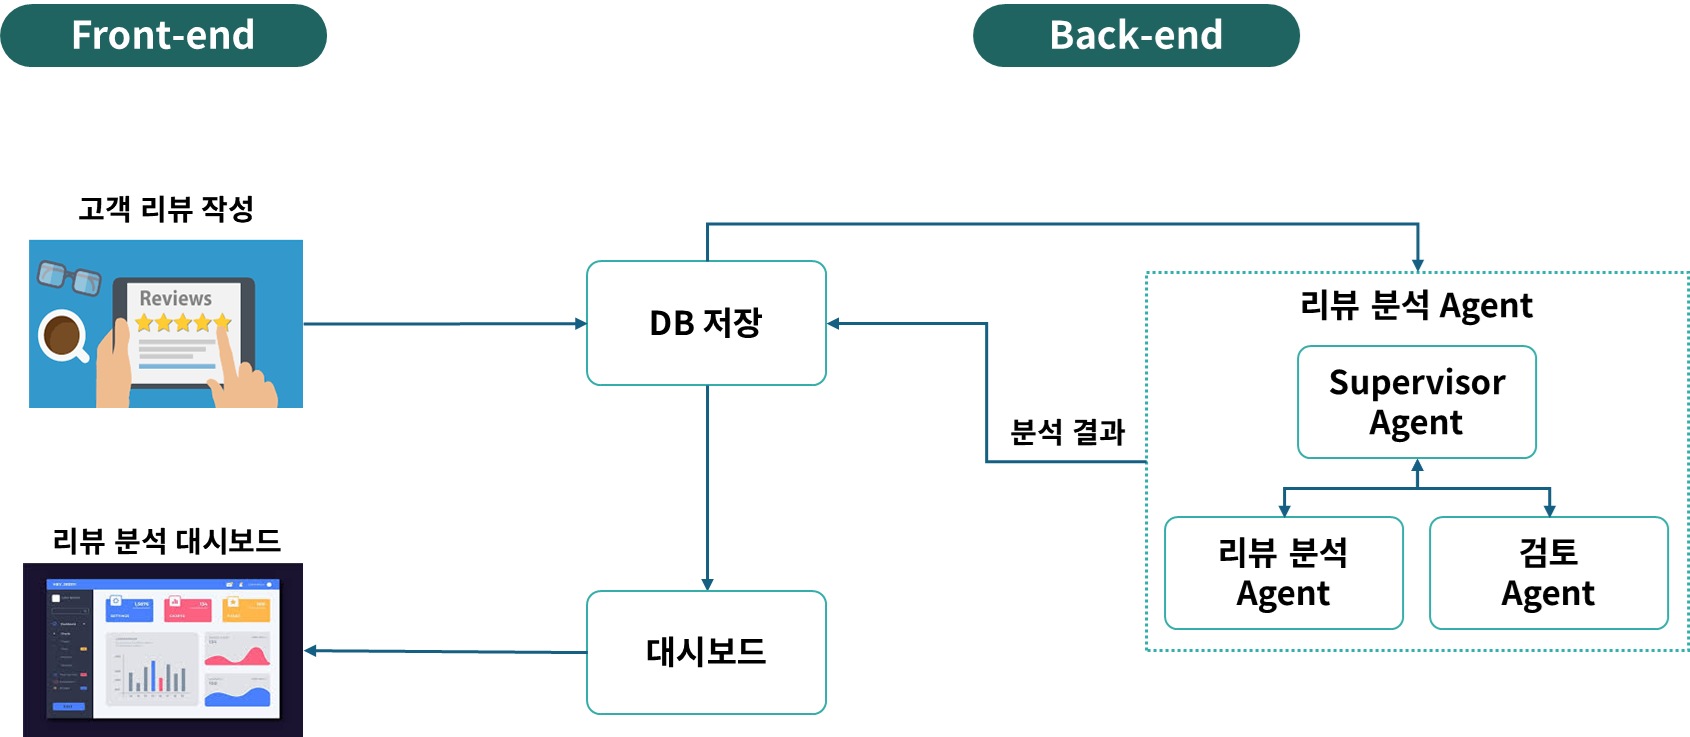

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더 `proj2_agent`를 생성(이미 만들었다면 skip)
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [249]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리

* 필요한 라이브러리 설치

In [250]:
!pip install -q langchain-openai langchain-community streamlit

* 라이브러리 로딩

In [251]:
# 기본 제공 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
import os
import openai
import ast
import re

from typing import TypedDict, Annotated, List, Optional, Literal, Dict, Any
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import END, START, StateGraph, MessagesState
from langchain_openai import ChatOpenAI

# 더 필요한 라이브러리가 있다면 추가합시다. -----




### (3) OpenAI API Key 확인

In [252]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/AIVLE School/project03/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

In [253]:
print(os.environ['OPENAI_API_KEY'][:30])

sk-proj-iW89cnUnCIOgDRwf4diLT-


## **2. 미션③ : langsmith 기반 운영 시스템**

* [필수] 실행 Trace : 설정 및 관측 결과 확인
* [선택항목] 다음 항목은 예시 입니다.
	* 평가 : 데이터셋 구성, 평가 지표 설정 및 확인
	* 실패(혹은 오류) 케이스를 만들고 추적 및 원인 분석

### **(1) langsmith 설정**

* langsmith trace에 project 추가 : `proj2_agent`


* 운영환경 설정

In [254]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "proj2_agent"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

In [255]:
from langsmith import Client
client = Client()

print("Available datasets in LangSmith:")
for dataset in client.list_datasets():
    print(f"- {dataset.name} (ID: {dataset.id})")

Available datasets in LangSmith:


### **(2) Step1 결과물**
* Step1의 결과물을 아래 붙여 넣습니다.

#### **1) State & LLM 준비**

In [256]:
class ReviewState(TypedDict):
    # 입력 리뷰
    review: str

    # 개별 에이전트 실행 결과
    analyzer_result: Optional[Dict[str, Any]]
    critic_result: Optional[Dict[str, Any]]
    retry_count: int
    max_retries: int

    # 흐름 제어 및 오케스트레이션 필수 키
    next_agent: Literal['analyzer', 'critic', 'end']
    critic_reason: Optional[str]

* llm 준비

In [257]:
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)

#### **2) Agent 노드 준비**
* 필요 Agent : Analyzer Agent, Critic Agent, Supervisor Agent
* 리뷰 결과 State에 담기게 되는 형식 : Dictionary(혹은 JSON)


* Analyzer Agent

In [258]:
def analyzer_node(state: ReviewState):
    review = state["review"]

    sys_msg = """# 역할 : 너는 상품 리뷰 분석 Agent.
# 목표 : 리뷰에서 언급된 속성만 추출하여 감성(긍정=1, 부정=0)을 판정.
# 속성 목록(이 4개만 허용): 보습, 가격, 향, 포장
# 규칙:
- 속성은 언급된 것만 포함한다. 없으면 items는 빈 리스트로 작성한다.
- label은 0 또는 1만 사용한다.
- 같은 속성(aspect)은 반드시 한 번만 출력한다.
- evidence는 해당 속성을 가장 잘 보여주는 대표 근거 1개만 작성한다.
- 출력은 오직 딕셔너리 1개만 작성한다.
"""
    human_msg = f"리뷰 : {review}"

    response = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

    try:
        parsed = ast.literal_eval(response.content)
    except:
        parsed = {"items": []}

    return {"analyzer_result": parsed}

* Critic Agent

In [259]:
def critic_node(state: ReviewState):
    review = state["review"]
    result = state.get("analyzer_result", {"items": []})

    sys_msg = """# 역할 : 너는 리뷰 분석 결과에 대한 검수 Agent.
# 목표 : 아래 분석 결과가 리뷰에 대한 분석결과에 대해 '적합', '부적합'으로 판단.
# 판단 기준
- '적합' : 분석 결과가 리뷰 내용과 일치하고, 근거(evidence)가 리뷰에서 확인 가능
- '부적합' : 리뷰에 없는 내용을 추론/추가했거나, 속성/감성 판단이 리뷰와 어긋남.
- 판단이 애매하면 '부적합'으로 보수적 판정
# 출력은 오직 Dictionary 1개만:
- verdict : 반드시 둘 중 하나만 : '적합', '부적합'
- reason : 판단 이유에 대해 짧게 핵심만 작성
"""
    human_msg = f"""주어진 리뷰와 분석 결과를 바탕으로 판단.
# 리뷰: {review}
# 분석 결과: {result}
"""

    response = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

    try:
        parsed = ast.literal_eval(response.content)
    except:
        parsed = {"verdict": "부적합", "reason": "파싱 에러"}

    return {"critic_result": parsed}

* Supervisor Agent

In [260]:
def supervisor_node(state: ReviewState):
    # 1. 초기 분석 시작
    if state.get("analyzer_result") is None:
        return {"next_agent": "analyzer"}

    # 2. 분석 완료 후 검수 요청
    if state.get("critic_result") is None:
        return {"next_agent": "critic"}

    # 3. 검수 결과 확인
    verdict = state["critic_result"].get("verdict", "부적합")

    if verdict == "적합":
        return {"next_agent": "end"}

    # 4. 재시도 제어
    retry = state.get("retry_count", 0)
    max_r = state.get("max_retries", 1)

    if retry >= max_r:
        return {"next_agent": "end"}

    # 상태 초기화 후 재시도
    return {
        "next_agent": "analyzer",
        "retry_count": retry + 1,
        "critic_result": None,
        "analyzer_result": None
    }

#### **3) 그래프 구성**

* route_next 함수

In [261]:
def route_next(state: ReviewState) -> str:
    return state["next_agent"]

* 그래프

In [262]:
graph = StateGraph(ReviewState)

graph.add_node("supervisor", supervisor_node)
graph.add_node("analyzer", analyzer_node)
graph.add_node("critic", critic_node)

graph.set_entry_point("supervisor")

# Worker는 항상 Supervisor로 반환
graph.add_edge("analyzer", "supervisor")
graph.add_edge("critic", "supervisor")

# Supervisor만 라우팅
graph.add_conditional_edges(
    "supervisor",
    route_next,
    {
        "analyzer": "analyzer",
        "critic": "critic",
        "end": END
    }
)

app = graph.compile()

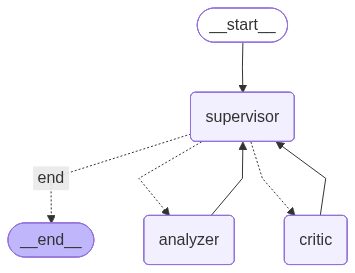

In [263]:
app

### **(3) 추적 확인**

예제 코드를 통해 추적을 확인해 봅시다.


In [264]:
from langsmith import Client

# 1. LangSmith 클라이언트 설정
client = Client()

# 2. 아까 웹에서 만든 데이터셋 이름 (이름이 'data'가 맞는지 확인하세요!)
dataset_name = "review_test_v2"

# 3. 데이터셋에서 리뷰 목록 가져오기
examples = list(client.list_examples(dataset_name=dataset_name))

print(f"📊 총 {len(examples)}개의 리뷰 데이터로 성능 테스트를 시작합니다.")

# 4. 루프 돌리며 에이전트 실행
for i, example in enumerate(examples):
    # 데이터셋의 'review' 컬럼 값을 가져옴
    review_text = example.inputs.get("review")

    if not review_text:
        continue

    print(f"[{i+1}/{len(examples)}] 분석 중: {review_text[:30]}...")

    # 5. 여러분의 'app' 객체에 바로 주입
    # 초기 상태(State)를 깨끗하게 정의해서 넣어줘야 에러가 안 납니다.
    app.invoke({
        "review": review_text,
        "analyzer_result": None,
        "critic_result": {},
        "retry_count": 0,
        "max_retries": 2,
        "next_agent": "analyzer"
    })

print("\n✅ 모든 리뷰 분석이 완료되었습니다!")
print("지금 바로 LangSmith의 [Datasets & Testing] 탭에서 QUALITY 점수를 확인해보세요!")

LangSmithNotFoundError: Dataset review_test_v2 not found

In [ ]:
review_to_save = "이 스마트폰 카메라는 정말 훌륭해요! 사진이 선명하고 색감도 좋아요. 그런데 가격이 너무 비싸서 구매를 망설였어요."

# Agent 실행 - 초기 State 정의
# KeyError 방지를 위해 ReviewState 구조에 맞게 초기값을 설정합니다.
init_state = {
    "review": review_to_save,
    "analyzer_result": None,
    "critic_result": None,
    "retry_count": 0,
    "max_retries": 2,
    "next_agent": "analyzer"  # route_next가 참조할 시작점 설정
}

try:
    # 그래프 실행
    final_state_save = app.invoke(init_state)

    # 결과 추출 및 DB 저장 로직
    analyzer_result = final_state_save.get('analyzer_result', {'items': []})
    items = analyzer_result.get('items', [])

    agent_aspect = json.dumps([item['aspect'] for item in items], ensure_ascii=False)
    agent_label = json.dumps([item['label'] for item in items], ensure_ascii=False)
    agent_evidence = json.dumps([item['evidence'] for item in items], ensure_ascii=False)

    # DB 연결 및 저장
    conn = sqlite3.connect(path + 'reviews.db')
    cursor = conn.cursor()

    cursor.execute("INSERT INTO reviews (review, agent_aspect, agent_label, agent_evidence) VALUES (?, ?, ?, ?)",
                   (review_to_save, agent_aspect, agent_label, agent_evidence))
    conn.commit()
    conn.close()

    print("Review (including evidence) saved to DB successfully.")

except KeyError as e:
    print(f"오류 발생: {e} 키가 State에 존재하지 않습니다. Graph 정의를 확인하세요.")
except Exception as e:
    print(f"예상치 못한 오류 발생: {e}")

## **3. 미션④ : Agent 고도화**

* [필수] Supervisor 중심 반복 제어
    - LLM 기반 흐름 제어
    - reason_code 기반 재시도 정책
* [필수] DB에 쌓인 리뷰 예측 batch 처리
* [선택항목] 다음은 예시 입니다.
    - 각 에이전트 고도화 : 성능/정확도를 높이기 위한 프롬프트 개선 등
    - HITL 노드 설계 : 특정 조건 시 Human Review 전환
    - 그 외 팀 내에서 추가 기능 검토 후 구현 가능


### **(1) Supervisor 중심 반복 제어**

* Supervisor Agent : 통제 정책 오케스트레이터(Policy Orchestrator)
    * Critic 판정이 ‘부적합’ 일 때 LLM은
        * critic_reason을 확인하여 reason_code 분류
        * 재시도 시 필요한 짧은 수정 지시를 repair_directive에 저장


#### **1) State 보완**

In [ ]:
ReasonCode = Literal["OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR", "OK"]

class ReviewState(TypedDict):
    # 입력 리뷰
    review: str

    # 개별 에이전트 실행 결과
    analyzer_result: Optional[Dict[str, Any]]   # {"items":[{"aspect":..., "label":..., "evidence":...}, ...]}
    critic_result: Optional[Dict[str, Any]]     # {"verdict":"적합|부적합", "reasons":"..."}

    # 흐름 제어
    retry_count: int
    max_retries: int
    next_agent: Literal["analyzer", "critic", "end"]

    reason_code: Optional[ReasonCode]
    repair_directive: Optional[str] # reason_code에 따른 짧은 수정 지시문

In [ ]:
ReasonCode = Literal[
    "OUTPUT_ERROR",
    "SCOPE_ERROR",
    "EVIDENCE_ERROR",
    "QUALITY_ERROR",
    "AMBIGUOUS_SENTIMENT", #감정판단 애매함
    "MIXED_SENTIMENT", #긍/부정 섞임
    "UNSUPPORTED_ASPECT", #허용하지 않은 속성
    "ok"
]

class ReviewState(TypedDict):
    review: str

    analyzer_result: Optional[Dict[str, Any]]
    critic_result: Optional[Dict[str, Any]]

    reason_code: Optional[ReasonCode]
    repair_directive: Optional[str]

    retry_count: int
    max_retries: int

    # HITL 추가
    human_decision: Optional[Literal["APPROVE", "REVISE","ABORT"]]
    human_reason: Optional[str]

    next_agent: Literal["analyzer", "critic", "human_review", "end"]

#### **2) Agent 노드 준비**

In [ ]:
# 정책 및 필요 함수 준비 : 아래 내용을 수정해서 사용하세요.

REASON_CODES = {"OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR", "OK"}
RETRYABLE = {"OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR"}

REPAIR_TEMPLATES = {
    "OUTPUT_ERROR": "dict 1개만 출력. 코드블록/설명 없이 items 구조와 label(0/1)을 맞춰라.",
    "SCOPE_ERROR": "aspect는 보습, 가격, 향, 포장만 사용하라. 다른 표현은 가장 가까운 값으로 매핑하라.",
    "EVIDENCE_ERROR": "evidence는 리뷰 원문에 실제로 있는 연속된 문구만 사용하라.",
    "QUALITY_ERROR": "리뷰에 없는 내용을 만들지 말고, 애매하면 해당 aspect는 제외하라."
}

# 딕셔너리 파싱 함
def parse_dict(text, default):
    try:
        return ast.literal_eval(text)
    except:
        return default

* HITL 보완 - 수민

In [ ]:
HITL_REQUIRED = {
    "AMBIGUOUS_SENTIMENT",
    "MIXED_SENTIMENT",
    "UNSUPPORTED_ASPECT",
    "QUALITY_ERROR"
}

def should_trigger_hitl(state: ReviewState) -> bool:
    critic_result = state.get("critic_result") or {}
    verdict = critic_result.get("verdict")
    reason_code = state.get("reason_code")

    retry_count = state.get("retry_count", 0)
    max_retries = state.get("max_retries", 2)

    # 정책 기준: 사람이 판단해야 하는 케이스
    if reason_code in HITL_REQUIRED:
        return True

    # 정량 기준: 재시도 횟수 초과
    if verdict == "부적합" and retry_count >= max_retries:
        return True

    return False

* Analyzer Agents 보완

In [ ]:
def analyzer_node(state: ReviewState):
    review = state["review"]

    repair_directive = state.get("repair_directive", "")

    # DB에서 현재 승인된 속성 목록을 실시간으로 읽어옴
    # → 관리자가 새 속성을 승인하면 다음 실행부터 자동 반영됨
    active_aspects = get_active_aspects()
    aspect_str = ", ".join(active_aspects)   # "보습, 가격, 향, 포장, 지속력" 형태

    sys_msg = f"""
# 역할 : 너는 상품 리뷰 분석 Agent.
# 목표 : 리뷰에서 언급된 속성만 추출하여 감성(긍정=1, 부정=0)을 판정.
# 속성 목록(이것만 허용): {aspect_str}
# 규칙:
- 속성은 언급된 것만 포함한다. 없으면 items는 빈 리스트로 작성.
- label은 0 또는 1만 사용한다.
- 같은 속성(aspect)은 반드시 한 번만 출력함. 리뷰에 같은 속성이 여러 번 등장해도 하나로 통합.
- evidence는 해당 속성을 가장 잘 보여주는 대표 근거 1개만 작성.
- 출력은 오직 Dictionary 1개만 작성.
- 설명, 코드블록, 마크다운은 포함하지 않음.
# 출력 구조 예시:
{{"items": [
    {{"aspect": "가격", "label": 0, "evidence": "가격이 조금 비싸요"}},
    {{"aspect": "포장", "label": 1, "evidence": "포장이 깔끔했어요"}}
]}}
"""
    human_msg = f"""다음 리뷰에 대해 상품 감성 분석 수행해.
    만약 수정 지시 내용이 있으면 반드시 반영해서 다시 분석해.
- 리뷰 : {review}
- 수정 지시 : {repair_directive}
"""

    response = llm.invoke([SystemMessage(content=sys_msg),
                      HumanMessage(content=human_msg)])
    parsed = ast.literal_eval(response.content) # 문자열을 딕셔너리로 변환

    return {"analyzer_result": parsed}

* Critic Agent 보완

In [ ]:
def critic_node(state: ReviewState):
    review = state["review"]
    analyzer_result = state["analyzer_result"]

    prompt = f"""
너는 상품 리뷰 분석 결과를 검수하는 Critic Agent다.

[원본 리뷰]
{review}

[Analyzer 분석 결과]
{analyzer_result}

아래 기준으로 분석 결과가 적합한지 판단하라.

[판단 기준]
- 리뷰에 언급된 속성만 추출했는가?
- aspect가 허용된 속성인지 확인하라.
- label이 리뷰 감성과 일치하는지 확인하라.
- evidence가 리뷰 원문에 실제로 존재하는지 확인하라.
- 감성 판단이 애매하거나 긍정/부정이 섞여 있으면 부적합으로 판단하라.

[reason_code 목록]
- OK
- OUTPUT_ERROR
- SCOPE_ERROR
- EVIDENCE_ERROR
- QUALITY_ERROR
- AMBIGUOUS_SENTIMENT
- MIXED_SENTIMENT
- UNSUPPORTED_ASPECT

[출력 형식]
반드시 아래 형식의 dict로만 출력하라.
{{
  "verdict": "적합" 또는 "부적합",
  "reason_code": "OK 또는 위 reason_code 중 하나",
  "reason": "판단 이유"
}}
"""

    response = llm.invoke(prompt)

    result = ast.literal_eval(response.content)

    return {
        "critic_result": result,
        "reason_code": result.get("reason_code", "QUALITY_ERROR")
    }

* Supervisor Agent 보완

In [ ]:
def supervisor_node(state: ReviewState):
    human_decision = state.get("human_decision")

    # 1) Human Review 결과 처리
    if human_decision:
        if human_decision == "APPROVE":
            return {
                "next_agent": "end"
            }

        if human_decision == "ABORT":
            return {
                "next_agent": "end"
            }

        if human_decision == "REVISE":
            return {
                "retry_count": state.get("retry_count", 0) + 1,
                "analyzer_result": None,
                "critic_result": None,
                "reason_code": None,
                "repair_directive": state.get("human_reason"),
                "human_decision": None,
                "human_reason": None,
                "next_agent": "analyzer"
            }

    # 2) Analyzer 결과가 없으면 Analyzer 실행
    if state.get("analyzer_result") is None:
        return {
            "next_agent": "analyzer"
        }

    # 3) Critic 결과가 없으면 Critic 실행
    if state.get("critic_result") is None:
        return {
            "next_agent": "critic"
        }

    # 4) Critic 결과 확인
    critic_result = state.get("critic_result") or {}
    verdict = critic_result.get("verdict")
    reason_code = state.get("reason_code")

    # 적합이면 종료
    if verdict == "적합":
        return {
            "next_agent": "end"
        }

    # 부적합이면 HITL 여부 판단
    if verdict == "부적합":
        if should_trigger_hitl(state):
            return {
                "next_agent": "human_review"
            }

        # HITL 대상이 아니면 자동 재시도
        return {
            "retry_count": state.get("retry_count", 0) + 1,
            "analyzer_result": None,
            "critic_result": None,
            "reason_code": None,
            "repair_directive": f"이전 분석 결과가 부적합입니다. reason_code={reason_code}를 참고하여 다시 분석하세요.",
            "next_agent": "analyzer"
        }

    # 예외 상황은 종료
    return {
        "next_agent": "end"
    }

* human review

In [ ]:
def human_review_node(state: ReviewState):
    print("\n===== HITL: Human Review Required =====")

    print("\n[원본 리뷰]")
    print(state.get("review"))

    print("\n[Analyzer 분석 결과]")
    print(state.get("analyzer_result"))

    print("\n[Critic 검수 결과]")
    print(state.get("critic_result"))

    print("\n[Reason Code]")
    print(state.get("reason_code"))

    print("\n가능한 결정: APPROVE / REVISE / ABORT")

    while True:
        decision = input("\n결정 입력: ").strip().upper()

        if decision in {"APPROVE", "REVISE", "ABORT"}:
            break

        print("잘못된 입력입니다. APPROVE / REVISE / ABORT 중 하나를 입력하세요.")

    human_reason = ""

    if decision == "REVISE":
        human_reason = input("수정 의견을 입력하세요: ").strip()

        while not human_reason:
            print("REVISE를 선택한 경우 수정 의견이 필요합니다.")
            human_reason = input("수정 의견을 입력하세요: ").strip()

    elif decision == "ABORT":
        human_reason = input("중단 사유를 입력하세요. 없으면 Enter: ").strip()

    else:
        human_reason = input("승인 의견을 입력하세요. 없으면 Enter: ").strip()

    return {
        "human_decision": decision,
        "human_reason": human_reason
    }

* route_next 함수

In [ ]:
def route_next(state: ReviewState) -> str:
    return state["next_agent"]

* 그래프

In [ ]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(ReviewState)

graph.add_node("supervisor", supervisor_node)
graph.add_node("analyzer", analyzer_node)
graph.add_node("critic", critic_node)
graph.add_node("human_review", human_review_node)

graph.add_edge(START, "supervisor")
graph.add_edge("analyzer", "supervisor")
graph.add_edge("critic", "supervisor")
graph.add_edge("human_review", "supervisor")

graph.add_conditional_edges(
    "supervisor",
    route_next,
    {
        "analyzer": "analyzer",
        "critic": "critic",
        "human_review": "human_review",
        "end": END
    }
)

app = graph.compile()

In [ ]:
app

### **(3) Insight Agent 추가: 요약 리포트 및 개선 제안 도출**
리뷰 데이터를 기반으로 전체적인 통계 요약과 향후 제품 개선을 위한 제안을 생성하는 Agent입니다.

In [ ]:
import os
import ast
import sqlite3
from typing import Optional, Dict, Any, List, Literal
from typing_extensions import TypedDict

from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, END

# ==========================================
# 1. State 및 Schema 정의
# ==========================================

class InsightState(TypedDict):
    # 입력 설정
    db_path: str
    n_reviews: int                        # 분석할 최근 N건 (0이면 전체)

    # db_loader 결과
    aspect_summary: Optional[Dict[str, Dict[str, int]]]
    total_reviews: Optional[int]

    # summarizer 결과
    summary_report: Optional[str]
    best_aspect: Optional[str]
    worst_aspect: Optional[str]
    overall_sentiment: Optional[str]

    # advisor 결과
    recommendations: Optional[List[Dict[str, Any]]]
    marketing_point: Optional[str]

    # 흐름 제어
    next_agent: Literal["db_loader", "summarizer", "advisor", "end"]
    error_message: Optional[str]


# 할루시네이션 방지를 위한 Pydantic Schema 정의
class SummarizerOutput(BaseModel):
    summary_report: str = Field(description="전체 리뷰를 분석한 자연어 요약 리포트 (수치 기반 근거 포함 필수)")
    best_aspect: str = Field(description="가장 긍정적인 속성 이름")
    worst_aspect: str = Field(description="가장 부정적인 속성 이름")
    overall_sentiment: str = Field(description="전체 브랜드 평판 수준 (긍정, 부정, 또는 혼재)")

class Recommendation(BaseModel):
    priority: int = Field(description="우선순위 (1~5)")
    aspect: str = Field(description="대상 속성")
    issue: str = Field(description="해당 속성의 주요 이슈 또는 강점")
    action: str = Field(description="구체적인 개선 또는 유지 액션")
    type: str = Field(description="해당 액션의 타입 (예: 마케팅, 제품개선 등)")

class AdvisorOutput(BaseModel):
    recommendations: List[Recommendation] = Field(description="구체적인 제품/서비스 개선 제안 리스트 (최소 2개, 최대 5개)")
    marketing_point: str = Field(description="긍정 속성을 강조할 마케팅 포인트 제안")

# ==========================================
# 2. Agent(Node) 함수 구현
# ==========================================

# (1) 데이터 로더 (DB 조회 및 집계)
def db_loader_node(state: InsightState):
    db_path = state.get("db_path", "reviews.db")
    n_reviews = state.get("n_reviews", 0)

    if not os.path.exists(db_path):
        return {"error_message": f"DB 파일이 존재하지 않습니다: {db_path}", "aspect_summary": {}}

    conn = sqlite3.connect(db_path)
    cur = conn.cursor()

    # 최근 N건 조회 (0이면 전체) - 테이블명 reviews로 수정
    query = "SELECT agent_aspect, agent_label FROM reviews ORDER BY id DESC"
    if n_reviews > 0:
        query += f" LIMIT {n_reviews}"

    try:
        cur.execute(query)
        rows = cur.fetchall()
    except Exception as e:
        conn.close()
        return {"error_message": f"DB 조회 실패: {str(e)}", "aspect_summary": {}}

    conn.close()

    if not rows:
        return {"error_message": "분석할 리뷰 데이터가 DB에 없습니다.", "aspect_summary": {}}

    # 속성별 긍정(pos)/부정(neg) 집계
    summary = {}
    valid_count = 0

    for aspect_str, label_str in rows:
        try:
            # 문자열로 저장된 리스트를 파싱
            aspects = json.loads(aspect_str) if aspect_str else []
            labels = json.loads(label_str) if label_str else []

            if not isinstance(aspects, list): aspects = [aspects]
            if not isinstance(labels, list): labels = [labels]

            valid_count += 1

            for asp, lbl in zip(aspects, labels):
                if asp not in summary:
                    summary[asp] = {"pos": 0, "neg": 0}

                if float(lbl) >= 0.6:
                    summary[asp]["pos"] += 1
                elif float(lbl) <= 0.4:
                    summary[asp]["neg"] += 1
        except Exception:
            continue

    return {
        "aspect_summary": summary,
        "total_reviews": valid_count
    }

# (2) 요약 리포트 생성기
def summarizer_node(state: InsightState):
    summary_data = state.get("aspect_summary", {})
    total = state.get("total_reviews", 0)

    llm_mini = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    structured_llm = llm_mini.with_structured_output(SummarizerOutput)

    sys_msg = """# 역할 : 너는 화장품 상품 리뷰의 속성별 집계 데이터를 분석하여 인사이트를 도출하는 요약 전문가야.
# 목표 : 속성별 긍정/부정 건수를 바탕으로 자연어 요약 리포트를 작성하고, 가장 좋은 속성과 나쁜 속성을 판단해.
# 제약 조건
- 입력받은 수치(집계 데이터)에 기반해서만 요약해. 데이터를 창작(Hallucination)하지 마.
- 요약 리포트에는 수치 데이터(예: 긍정 80% 등)를 반드시 포함하여 근거를 제시해.
"""
    human_msg = f"""다음은 최근 {total}건의 리뷰 분석 결과(속성별 긍정/부정 건수)야.
분석 결과: {summary_data}

이 데이터를 바탕으로 요약 리포트를 작성해 줘.
"""

    response = structured_llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

    return {
        "summary_report": response.summary_report,
        "best_aspect": response.best_aspect,
        "worst_aspect": response.worst_aspect,
        "overall_sentiment": response.overall_sentiment
    }

# (3) 개선 제안 생성기
def advisor_node(state: InsightState):
    summary_report = state.get("summary_report", "")
    best = state.get("best_aspect", "")
    worst = state.get("worst_aspect", "")
    summary_data = state.get("aspect_summary", {})

    llm_mini = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    structured_llm = llm_mini.with_structured_output(AdvisorOutput)

    sys_msg = """# 역할 : 너는 뷰티/화장품 산업의 프로덕트 매니저이자 마케팅 전문가야.
# 목표 : 리뷰 요약 리포트를 읽고 구체적이고 실행 가능한 제품/서비스 개선 제안을 작성해.
# 제약 조건
- 요약된 사실(수치)을 기반으로 작성해.
- 긍정 비율이 높은 속성은 마케팅 포인트로 삼고, 부정 비율이 높은 속성은 제품 개선 아이디어로 제시해.
- 제안(recommendations)은 우선순위가 높은 순으로 2개에서 최대 5개까지만 도출해.
"""
    human_msg = f"""다음 요약 리포트와 베스트/워스트 속성 정보를 참고해서 개선 제안을 작성해 줘.
# 요약 리포트: {summary_report}
# 베스트 속성: {best}
# 워스트 속성: {worst}
# 상세 데이터: {summary_data}
"""

    response = structured_llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

    recs = [rec.model_dump() for rec in response.recommendations]

    return {
        "recommendations": recs,
        "marketing_point": response.marketing_point
    }

# (4) 오케스트레이터 (라우팅)
def insight_supervisor(state: InsightState):
    if state.get("error_message"):
        return {"next_agent": "end"}

    if state.get("aspect_summary") is None:
        return {"next_agent": "db_loader"}

    if state.get("summary_report") is None:
        return {"next_agent": "summarizer"}

    if state.get("recommendations") is None:
        return {"next_agent": "advisor"}

    return {"next_agent": "end"}

def route_insight(state: InsightState) -> str:
    return state["next_agent"]

# ==========================================
# 3. 그래프 구성 및 빌드
# ==========================================

insight_graph = StateGraph(InsightState)

insight_graph.add_node("insight_supervisor", insight_supervisor)
insight_graph.add_node("db_loader", db_loader_node)
insight_graph.add_node("summarizer", summarizer_node)
insight_graph.add_node("advisor", advisor_node)

insight_graph.set_entry_point("insight_supervisor")

insight_graph.add_edge("db_loader", "insight_supervisor")
insight_graph.add_edge("summarizer", "insight_supervisor")
insight_graph.add_edge("advisor", "insight_supervisor")

insight_graph.add_conditional_edges(
    "insight_supervisor",
    route_insight,
    {
        "db_loader": "db_loader",
        "summarizer": "summarizer",
        "advisor": "advisor",
        "end": END
    }
)

insight_app = insight_graph.compile()

### **(4) Insight Agent 실행 및 결과 시각화**
DB에 저장된 실제 리뷰 데이터를 바탕으로 인사이트를 도출합니다.

In [ ]:
# Insight Agent 실행 설정
insight_init_state = {
    "db_path": path + 'reviews.db',  # 실제 DB 경로
    "n_reviews": 0,                 # 0은 전체 데이터 분석
    "aspect_summary": None,
    "total_reviews": None,
    "summary_report": None,
    "best_aspect": None,
    "worst_aspect": None,
    "overall_sentiment": None,
    "recommendations": None,
    "marketing_point": None,
    "next_agent": "db_loader",
    "error_message": None
}

# 그래프 실행
try:
    insight_result = insight_app.invoke(insight_init_state)

    if insight_result.get("error_message"):
        print(f"❌ 분석 중 오류 발생: {insight_result['error_message']}")
    else:
        print("\n" + "="*50)
        print("📊 상품 리뷰 분석 인사이트 리포트")
        print("="*50)
        print(f"\n[총 분석 리뷰 수]: {insight_result.get('total_reviews')}건")
        print(f"[전체 브랜드 평판]: {insight_result.get('overall_sentiment')}")
        print(f"[최고의 속성]: {insight_result.get('best_aspect')}")
        print(f"[개선 필요 속성]: {insight_result.get('worst_aspect')}")

        print("\n[요약 리포트]")
        print(insight_result.get("summary_report"))

        print("\n[🎯 마케팅 포인트]")
        print(insight_result.get("marketing_point"))

        print("\n[💡 실행 제안 (Action Items)]")
        for rec in insight_result.get("recommendations", []):
            print(f"- [{rec['aspect']}] (우선순위: {rec['priority']}): {rec['action']}")

except Exception as e:
    print(f"실행 중 예외 발생: {e}")

* 실행 테스트

In [ ]:
review = '''
잘 사용하고 있어요. 보습력도 좋고 향도 좋아서 잘 사용합니다.
용량도 커서 부담없이 자주 바르고 있어요.
앞으로도 잘 사용할 것 같아요. 보습력 향 모두 만족하는 상품입니다.
'''

init_state: ReviewState = {
        "review": review,
        "analyzer_result": None,
        "critic_result": None,
        "retry_count": 0,
        "max_retries": 2,
        "next_agent": "analyzer",
    }

result = app.invoke(init_state)
result

In [ ]:
# reason_code 테스트 ('SCOPE_ERROR')

review = "texture가 정말 좋고 흡수력도 빠르네요. 피부결이 확실히 달라졌어요."

init_state: ReviewState = {
        "review": review,
        "analyzer_result": None,
        "critic_result": None,
        "retry_count": 0,
        "max_retries": 1,
        "next_agent": "analyzer",
    }

result = app.invoke(init_state)
result

In [ ]:
# reason_code 테스트 (max_retries 조정 -> "OK")

review = "texture가 정말 좋고 흡수력도 빠르네요. 피부결이 확실히 달라졌어요."

init_state: ReviewState = {
        "review": review,
        "analyzer_result": None,
        "critic_result": None,
        "retry_count": 0,
        "max_retries": 4,
        "next_agent": "analyzer",
    }

result = app.invoke(init_state)
result

### **(2) DB에 쌓인 리뷰 예측 batch 처리**

* 리뷰 데이터 여러 건을 임의로 생성하여 Step1에서 생성한 DB의 테이블에 저장.
* DB에서 분석 대상 리뷰 조회(예: agent_aspect가 NULL인 데이터)
* 각 리뷰에 대해 Agent 실행
* 분석 결과(items)에서 aspect , label 추출
* DB에 결과 저장 (UPDATE)


#### **1) 데이터 준비**
* data.csv 파일 로딩
* review 칼럼의 값만 DB에 저장

In [ ]:
# 코랩에 파일 업로드
from google.colab import files
uploaded = files.upload()

In [ ]:
# ── [추가] aspects 테이블 생성 및 기본값 삽입 ──────────────────
DB_PATH = path + "reviews.db"

conn = sqlite3.connect(DB_PATH)
cur  = conn.cursor()

cur.execute("""
    CREATE TABLE IF NOT EXISTS aspects (
        id         INTEGER PRIMARY KEY AUTOINCREMENT,
        aspect     TEXT    NOT NULL UNIQUE,
        status     TEXT    DEFAULT 'active',   -- active: 사용중 / pending: 승인대기 / rejected: 거절
        created_at DATETIME DEFAULT CURRENT_TIMESTAMP
    )
""")

# 기존 하드코딩 속성 4개를 기본값으로 삽입
# INSERT OR IGNORE → 이미 있으면 넘어감
for a in ["보습", "가격", "향", "포장"]:
    cur.execute(
        "INSERT OR IGNORE INTO aspects (aspect, status) VALUES (?, 'active')", (a,)
    )

conn.commit()
conn.close()
print("[aspects 테이블 준비 완료]")

# DB에서 active 속성만 꺼내는 헬퍼 함수
# → analyzer_node와 suggest_new_aspects 둘 다 이 함수를 사용함
def get_active_aspects(db_path=DB_PATH) -> List[str]:
    conn = sqlite3.connect(db_path)
    cur  = conn.cursor()
    cur.execute("SELECT aspect FROM aspects WHERE status = 'active'")
    aspects = [r[0] for r in cur.fetchall()]
    conn.close()
    return aspects

In [ ]:
# # agent_evidence 컬럼 추가 (최초 1회만 실행)
# conn = sqlite3.connect(path + 'reviews.db')
# cursor = conn.cursor()
# try:
#     cursor.execute("ALTER TABLE reviews ADD COLUMN agent_evidence TEXT")
#     conn.commit()
#     print("[agent_evidence 컬럼 추가 완료]")
# except:
#     print("[agent_evidence 컬럼 이미 존재]")
# conn.close()


# def batch_process_reviews(db_path, agent_app):
#     conn = sqlite3.connect(db_path)
#     cursor = conn.cursor()

#     # 1) 미처리 리뷰 조회
#     cursor.execute("SELECT id, review FROM reviews WHERE agent_aspect IS NULL OR agent_aspect = ''")
#     unprocessed_reviews = cursor.fetchall()

#     if not unprocessed_reviews:
#         print("분석할 새로운 리뷰가 없습니다.")
#         conn.close()
#         return

#     print(f"총 {len(unprocessed_reviews)}건의 리뷰 분석을 시작합니다.")

#     for row_id, review_text in unprocessed_reviews:
#         print(f"\n[ID {row_id}] 분석 중...")
#         try:
#             initial_state: ReviewState = {
#                 "review":           review_text,
#                 "analyzer_result":  None,
#                 "critic_result":    None,
#                 "reason_code":      None,
#                 "repair_directive": None,
#                 "retry_count":      0,
#                 "max_retries":      2,
#                 "next_agent":       "analyzer",
#             }
#             final_state = agent_app.invoke(initial_state)

#             # 2) aspect, label, evidence 추출 (None 방어)
#             analyzer_result = final_state.get('analyzer_result') or {'items': []}
#             items = analyzer_result.get('items', [])
#             agent_aspect   = json.dumps([item.get('aspect')  for item in items], ensure_ascii=False)
#             agent_label    = json.dumps([item.get('label')   for item in items], ensure_ascii=False)
#             agent_evidence = json.dumps([item.get('evidence') for item in items], ensure_ascii=False)

#             # 3) DB 업데이트
#             cursor.execute("""
#                 UPDATE reviews
#                 SET agent_aspect   = ?,
#                     agent_label    = ?,
#                     agent_evidence = ?,
#                     updated_at     = CURRENT_TIMESTAMP
#                 WHERE id = ?
#             """, (agent_aspect, agent_label, agent_evidence, row_id))
#             conn.commit()
#             print(f"  → 완료 | aspect={agent_aspect} | label={agent_label}")

#         except Exception as e:
#             print(f"  [오류] ID={row_id}: {e}")

#     conn.close()
#     print("\n[Batch 완료]")


# # 배치 실행
# batch_process_reviews(path + 'reviews.db', app)

# # 실행 결과 확인
# conn = sqlite3.connect(path + 'reviews.db')
# df_reviews = pd.read_sql_query("SELECT * FROM reviews", conn)
# conn.close()
# display(df_reviews)

In [ ]:
# import sqlite3

# # 1. 다시 정의한 테스트용 미분석 리뷰 데이터
# test_reviews = [
#     "보습력이 정말 좋네요. 그런데 향은 제 취향이 아니에요.",
#     "가격은 비싼 편이지만 그만큼 성능이 확실합니다.",
#     "배송이 너무 느려서 실망했어요. 상품은 괜찮은데 말이죠."
# ]

# # 2. DB에 데이터 삽입 (agent_aspect, agent_label을 비워둠)
# conn = sqlite3.connect(path + 'reviews.db')
# cursor = conn.cursor()

# for r_text in test_reviews:
#     cursor.execute("INSERT INTO reviews (review, agent_aspect, agent_label) VALUES (?, NULL, NULL)", (r_text,))

# conn.commit()
# print(f"{len(test_reviews)}건의 새로운 미분석 리뷰가 DB에 추가되었습니다.")

# conn.close()

In [ ]:
# def process_batch_reviews(db_path):
#     conn = sqlite3.connect(db_path)
#     cursor = conn.cursor()

#     cursor.execute("SELECT id, review FROM reviews WHERE agent_aspect IS NULL OR agent_aspect = ''")
#     unprocessed_reviews = cursor.fetchall()

#     if not unprocessed_reviews:
#         print("분석할 새로운 리뷰가 없습니다.")
#         conn.close()
#         return

#     print(f"총 {len(unprocessed_reviews)}건의 리뷰 분석을 시작합니다.")

#     for row_id, review_text in unprocessed_reviews:
#         print(f"\n[ID {row_id}] 분석 중...")

#         try:
#             final_state = app.invoke({"review_text": review_text, "reanalysis_attempts": 0})
#             result = final_state.get('analyzer_output', {})

#             aspects_json = json.dumps(result.get('aspects', []), ensure_ascii=False)
#             labels_json = json.dumps(result.get('sentiments', []), ensure_ascii=False)
#             # 배치 처리에도 근거 문장 저장 추가
#             evidence_json = json.dumps(final_state.get('agent_evidence', []), ensure_ascii=False)

#             cursor.execute("""
#                 UPDATE reviews
#                 SET agent_aspect = ?, agent_label = ?, agent_evidence = ?, update_at = CURRENT_TIMESTAMP
#                 WHERE id = ?
#             """, (aspects_json, labels_json, evidence_json, row_id))

#             conn.commit()
#             print(f"[ID {row_id}] 분석 완료 및 근거 저장 성공")

#         except Exception as e:
#             print(f"[ID {row_id}] 처리 중 오류 발생: {e}")

#     conn.close()
#     print("\n모든 배치 작업이 완료되었습니다.")

# process_batch_reviews(path + 'reviews.db')

#### **2) 리뷰를 읽어서 Agent 실행후 결과 저장**

In [ ]:
def batch_process_reviews(db_path, agent_app):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    # 1) 미처리 리뷰 조회 함수
    cursor.execute("SELECT id, review FROM reviews WHERE agent_aspect IS NULL OR agent_aspect = ''")
    unprocessed_reviews = cursor.fetchall()

    if not unprocessed_reviews:
        print("분석할 새로운 리뷰가 없습니다.")
        conn.close()
        return

    print(f"총 {len(unprocessed_reviews)}건의 리뷰 분석을 시작합니다.")

    for row_id, review_text in unprocessed_reviews:
        print(f"\n[ID {row_id}] 분석 중...")

        try:
            # Initialize ReviewState for the agent
            initial_state: ReviewState = {
                "review": review_text,
                "analyzer_result": None,
                "critic_result": None,
                "retry_count": 0,
                "max_retries": 2, # Set a default max_retries
                "next_agent": "analyzer",
            }
            final_state = agent_app.invoke(initial_state)

            # 2) Agent 결과에서 aspect, label, evidence 추출 함수
            analyzer_result = final_state.get('analyzer_result', {'items': []})
            agent_aspect = json.dumps([item['aspect'] for item in analyzer_result['items']], ensure_ascii=False)
            agent_label = json.dumps([item['label'] for item in analyzer_result['items']], ensure_ascii=False)
            # The new ReviewState doesn't directly return 'agent_evidence', it's within analyzer_result['items']
            # So, we'll extract evidence from analyzer_result['items']
            agent_evidence = json.dumps([item['evidence'] for item in analyzer_result['items']], ensure_ascii=False)

            # 3) DB 업데이트
            cursor.execute("""
                UPDATE reviews
                SET agent_aspect = ?, agent_label = ?, agent_evidence = ?, updated_at = CURRENT_TIMESTAMP
                WHERE id = ?
            """, (agent_aspect, agent_label, agent_evidence, row_id))

            conn.commit()
            print(f"[ID {row_id}] 분석 완료 및 근거 저장 성공")

        except Exception as e:
            print(f"[ID {row_id}] 처리 중 오류 발생: {e}")

    conn.close()
    print("\n모든 배치 작업이 완료되었습니다.")

In [ ]:
def suggest_new_aspects(db_path=DB_PATH):
    """
    전체 리뷰를 LLM에게 보여주고, 현재 허용 목록에 없는
    새 속성 후보를 제안받아 DB에 pending 상태로 저장.
    """
    # 현재 active 속성 (이미 있는 것은 제안 제외)
    active = get_active_aspects(db_path)

    # 리뷰 샘플 로딩 (최대 30건)
    conn = sqlite3.connect(db_path)
    df   = pd.read_sql_query("SELECT review FROM reviews", conn)
    conn.close()

    sample_size = min(30, len(df))
    reviews_sample = "\n".join(df["review"].dropna().sample(sample_size).tolist())

    sys_msg = """너는 상품 리뷰 분석 전문가다.
주어진 리뷰들을 읽고, 현재 허용 속성 목록에 없지만
자주 언급되는 새로운 속성 후보를 최대 5개 제안해라.

규칙:
- 현재 허용 목록에 있는 속성은 절대 제안하지 않는다.
- 15건 이상의 리뷰에서 언급된 것만 제안한다.
- 출력은 딕셔너리 1개만: {"candidates": ["속성1", "속성2", ...]}
- 후보가 없으면 {"candidates": []} 로 출력한다.
"""
    human_msg = f"""현재 허용 속성: {active}

리뷰 샘플:
{reviews_sample}
"""

    resp   = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])
    result = parse_dict(resp.content, {"candidates": []})
    candidates = result.get("candidates", [])

    if not candidates:
        print("[새 속성 후보 없음]")
        return []

    # DB에 pending 상태로 저장
    # → active가 아니므로 analyzer에는 아직 반영 안 됨
    # → Streamlit에서 관리자가 승인해야 active로 변경됨
    conn = sqlite3.connect(db_path)
    cur  = conn.cursor()
    for c in candidates:
        cur.execute(
            "INSERT OR IGNORE INTO aspects (aspect, status) VALUES (?, 'pending')",
            (c,)
        )
    conn.commit()
    conn.close()

    print(f"[후보 제안 완료] {candidates} → DB에 pending 상태로 저장됨")
    return candidates


# 배치 실행 후 호출
# batch_process_reviews(path + 'reviews.db', app)
suggest_new_aspects()

In [ ]:
# 배치 실행
batch_process_reviews(path + 'reviews.db', app)

# 실행 결과 확인
conn = sqlite3.connect(path + 'reviews.db')
df_reviews = pd.read_sql_query("SELECT * FROM reviews", conn)
conn.close()

display(df_reviews)

In [ ]:
# ── 속성 현황 확인 ──────────────────────────────────────────────
conn = sqlite3.connect(DB_PATH)
df_aspects = pd.read_sql_query(
    "SELECT * FROM aspects ORDER BY status, id", conn
)
conn.close()

print(f"[전체 속성 수] {len(df_aspects)}개\n")

for status, group in df_aspects.groupby("status"):
    label = {"active": "✅ 현재 사용 중", "pending": "🕐 승인 대기", "rejected": "❌ 거절됨"}.get(status, status)
    print(f"{label} ({len(group)}개): {list(group['aspect'])}")

print()
df_aspects   # DataFrame으로도 출력

In [ ]:
# ── suggest_new_aspects 단계별 결과 확인 ───────────────────────

# 1단계: 현재 active 속성 확인
active = get_active_aspects()
print(f"[1단계] 현재 active 속성: {active}")

# 2단계: 리뷰 샘플 확인
conn = sqlite3.connect(DB_PATH)
df_reviews = pd.read_sql_query("SELECT review FROM reviews", conn)
conn.close()

sample_size = min(30, len(df_reviews))
reviews_sample = df_reviews["review"].dropna().sample(sample_size, random_state=42).tolist()
print(f"\n[2단계] 샘플링된 리뷰 수: {sample_size}건")
print(f"  샘플 예시 (첫 3건):")
for r in reviews_sample[:3]:
    print(f"  - {r[:50]}...")

# 3단계: LLM 제안 결과 확인
print(f"\n[3단계] LLM 속성 후보 제안 중...")
candidates = suggest_new_aspects()
print(f"\n[3단계 완료] 제안된 후보: {candidates}")

# 4단계: DB 저장 결과 확인
conn = sqlite3.connect(DB_PATH)
df_after = pd.read_sql_query(
    "SELECT * FROM aspects ORDER BY status, id", conn
)
conn.close()
print(f"\n[4단계] DB 저장 후 aspects 테이블:")
print(df_after.to_string(index=False))

In [ ]:
DB_PATH = path + "reviews.db"
conn = sqlite3.connect(DB_PATH)
df_check = pd.read_sql_query("SELECT * FROM reviews", conn)
conn.close()

print(f"[전체 레코드 수] {len(df_check)}건")
df_check[50:100]

## **4. 미션⑤ : 대시보드 만들기**

### (1) 한글 폰트 준비

* 한글폰트 설치

In [ ]:
!apt-get -y install fonts-nanum

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (나눔바른고딕)
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

print(f"설정된 폰트: {font_name}")

* 세션 다시시작

### **(2) 대시보드 앱 : app.py**

* 최소 요구사항
    * 프레임1 : 상품리뷰 결과를 분석하는 그래프
    * 프레임2 : 리뷰 분석 결과 건별 조회


In [270]:
%%writefile app.py
import streamlit as st
import sqlite3
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from typing import TypedDict, Optional, Dict, Any, Literal, List
import os
import ast
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END

# ============================================
# 1. 기본 설정 및 폰트 세팅
# ============================================
# DB_PATH = "/content/drive/MyDrive/AIVLE/미니프로젝트3차/reviews.db"
DB_PATH = '/content/drive/MyDrive/AIVLE School/project03/reviews.db'


st.set_page_config(
    page_title="상품 리뷰 분석 AI",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ============================================
# 2. 커스텀 CSS 스타일링
# ============================================
st.markdown("""
<style>
    /* 전역 스타일 */
    :root {
        --primary: #2563eb;
        --primary-light: #3b82f6;
        --success: #10b981;
        --danger: #ef4444;
        --warning: #f59e0b;
        --gray-dark: #1f2937;
        --gray-light: #f3f4f6;
    }

    /* 메인 컨테이너 */
    .main {
        padding: 2rem 1rem;
    }

    /* 제목 스타일 */
    h1 {
        background: linear-gradient(135deg, #2563eb 0%, #3b82f6 100%);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
        background-clip: text;
        font-weight: 700;
        font-size: 2.5rem;
        margin-bottom: 0.5rem;
    }

    h2 {
        color: #1f2937;
        font-weight: 600;
        font-size: 1.5rem;
        margin-top: 1.5rem;
        margin-bottom: 1rem;
    }

    h3 {
        color: #374151;
        font-weight: 600;
        font-size: 1.125rem;
    }

    h4 {
        color: #1f2937;
        font-weight: 600;
        font-size: 1rem;
    }

    /* 버튼 스타일 */
    .stButton > button {
        background: linear-gradient(135deg, #2563eb 0%, #3b82f6 100%);
        color: white;
        border: none;
        border-radius: 0.5rem;
        padding: 0.75rem 2rem;
        font-weight: 600;
        font-size: 1rem;
        transition: all 0.3s ease;
        box-shadow: 0 4px 12px rgba(37, 99, 235, 0.2);
    }

    .stButton > button:hover {
        box-shadow: 0 6px 20px rgba(37, 99, 235, 0.35);
        transform: translateY(-2px);
    }

    /* 텍스트 영역 */
    .stTextArea > div > div > textarea {
        border: 2px solid #e5e7eb !important;
        border-radius: 0.5rem;
        font-size: 1rem;
        transition: border-color 0.3s ease;
    }

    .stTextArea > div > div > textarea:focus {
        border-color: #2563eb !important;
        box-shadow: 0 0 0 3px rgba(37, 99, 235, 0.1);
    }

    /* 탭 스타일 */
    .stTabs [data-baseweb="tab-list"] {
        gap: 1rem;
        background: transparent;
    }

    .stTabs [data-baseweb="tab"] {
        padding: 0.75rem 1.5rem;
        border-radius: 0.5rem;
        background: #f3f4f6;
        border: none;
        color: #6b7280;
        font-weight: 500;
        transition: all 0.3s ease;
    }

    .stTabs [aria-selected="true"] {
        background: linear-gradient(135deg, #2563eb 0%, #3b82f6 100%);
        color: white;
    }

    /* 메트릭 카드 */
    .metric-card {
        background: white;
        border-radius: 0.75rem;
        padding: 1.5rem;
        border: 1px solid #e5e7eb;
        box-shadow: 0 1px 3px rgba(0, 0, 0, 0.05);
        transition: all 0.3s ease;
    }

    .metric-card:hover {
        border-color: #2563eb;
        box-shadow: 0 4px 12px rgba(37, 99, 235, 0.1);
    }

    /* 상태 박스 */
    .stStatus {
        border-radius: 0.75rem;
        border-left: 4px solid #2563eb;
        background: #eff6ff;
    }

    /* 알림 박스 */
    .stAlert {
        border-radius: 0.75rem;
        border-left: 4px solid;
    }

    .stInfo {
        border-left-color: #2563eb;
        background-color: #eff6ff;
    }

    .stSuccess {
        border-left-color: #10b981;
        background-color: #ecfdf5;
    }

    .stWarning {
        border-left-color: #f59e0b;
        background-color: #fffbeb;
    }

    .stError {
        border-left-color: #ef4444;
        background-color: #fee2e2;
    }

    /* 데이터프레임 */
    .stDataFrame {
        border-radius: 0.75rem;
        overflow: hidden;
        border: 1px solid #e5e7eb;
    }

    /* 사이드바 */
    .sidebar .sidebar-content {
        padding: 2rem 1rem;
    }

    /* 구분선 */
    .stDivider {
        margin: 2rem 0;
        border: none;
        border-top: 1px solid #e5e7eb;
    }
</style>
""", unsafe_allow_html=True)

@st.cache_resource
def setup_font():
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if os.path.exists(font_path):
        fe = fm.FontEntry(fname=font_path, name='NanumBarunGothic')
        fm.fontManager.ttflist.insert(0, fe)
        plt.rc('font', family='NanumBarunGothic')
        plt.rcParams['axes.unicode_minus'] = False
        return 'NanumBarunGothic'
    return 'sans-serif'

font_name = setup_font()

# ============================================
# 3. 데이터베이스 및 유틸리티 함수
# ============================================
def get_all_data():
    try:
        conn = sqlite3.connect(DB_PATH)
        df = pd.read_sql_query("SELECT * FROM reviews ORDER BY id DESC", conn)
        conn.close()
        return df
    except:
        return pd.DataFrame()

def insert_review(review, aspects, labels, evidence):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("""
        INSERT INTO reviews (review, agent_aspect, agent_label, agent_evidence, update_at)
        VALUES (?, ?, ?, ?, CURRENT_TIMESTAMP)
    """, (review, json.dumps(aspects, ensure_ascii=False), json.dumps(labels, ensure_ascii=False), json.dumps(evidence, ensure_ascii=False)))
    conn.commit()
    conn.close()

def create_sentiment_chart(sentiments):
    """감정 분석 결과 파이 차트 생성"""
    counts = {'긍정': sentiments.count(1), '부정': sentiments.count(0)}

    fig, ax = plt.subplots(figsize=(5, 4))
    colors = ['#10b981', '#ef4444']
    explode = (0.05, 0.05)

    wedges, texts, autotexts = ax.pie(
        counts.values(),
        labels=counts.keys(),
        autopct='%1.1f%%',
        colors=colors,
        explode=explode,
        startangle=90,
        textprops={'fontsize': 11, 'weight': 'bold'}
    )

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(12)

    ax.set_title('감정 분석 결과', fontsize=13, weight='bold', pad=20)
    fig.patch.set_alpha(0)

    return fig

# ============================================
# 4. 헤더 및 네비게이션
# ============================================
col1, col2 = st.columns([3, 1])
with col1:
    st.markdown("# 📊 리뷰 분석 대시보드")
with col2:
    st.markdown("""
    <div style='text-align: right; padding: 1rem 0;'>
        <span style='color: #6b7280; font-size: 0.875rem;'>AI-Powered Analytics</span>
    </div>
    """, unsafe_allow_html=True)

st.markdown("""
<div style='height: 1px; background: linear-gradient(90deg, transparent, #e5e7eb, transparent); margin: 1rem 0;'></div>
""", unsafe_allow_html=True)

# ============================================
# 5. 메인 탭 구성
# ============================================
tab1, tab2, tab3 = st.tabs(["📊 리뷰 분석", "💡 인사이트", "⚙️ 속성 관리"])

with tab1:
    # --- 리뷰 분석 섹션 ---
    st.markdown("### ✍️ 새 리뷰 분석하기")

    col1, col2 = st.columns([5, 1], gap="medium")
    with col1:
        user_review = st.text_area(
            "분석할 리뷰 입력",
            height=120,
            placeholder="상품에 대한 고객 리뷰를 입력하세요. AI가 자동으로 분석해드립니다.",
            label_visibility="collapsed"
        )

    with col2:
        st.markdown("<div style='height: 0.5rem;'></div>", unsafe_allow_html=True)
        analyze_btn = st.button("🚀 분석 시작", use_container_width=True, key="analyze_btn")

    if analyze_btn:
        if user_review.strip():
            with st.status("분석 진행 중...", expanded=True) as status:
                st.write("🔄 리뷰를 분석하고 있습니다...")
                st.write("✓ 감정 분석 완료")
                st.write("✓ 주요 측면 추출 완료")

                st.warning("💡 **참고**: 실제 분석을 위해서는 LangGraph 정의가 필요합니다.")

            st.success("✅ 분석이 완료되었습니다!")
            # --- Critic 검수 결과 추가 ---
            st.subheader("🔍 Critic 검수 결과")
            critic_result = {
                "verdict": "부적합",
                "reason_code": "SCOPE_ERROR",
                "reason": "리뷰에 언급된 모든 속성이 반영되지 않았습니다."
            }
            st.write("판정:", critic_result.get("verdict"))
            st.write("실패 코드:", critic_result.get("reason_code"))
            st.write("사유:", critic_result.get("reason"))
            retry_count = 2
            # --- 시도 횟수 추가 ---
            st.write("재시도 횟수:", retry_count)
            if retry_count == 0:
                st.success("한 번에 분석 성공")
            else:
                st.warning(f"{retry_count}회 재시도 후 분석 완료")
        else:
            st.error("⚠️ 리뷰를 입력해주세요.")

    st.markdown("---")

    # --- 통계 섹션 ---
    df = get_all_data()
    if not df.empty:
        st.markdown("### 📈 분석 통계")

        # 메트릭 카드
        col1, col2, col3 = st.columns(3)
        with col1:
            st.metric("총 분석 리뷰 수", len(df), delta="+2개 (이번주)")
        with col2:
            try:
                all_sentiments = []
                for s_str in df['agent_label'].dropna():
                    try:
                        labels = json.loads(s_str)
                        all_sentiments.extend(labels)
                    except:
                        pass
                if all_sentiments:
                    positive_rate = (all_sentiments.count(1) / len(all_sentiments) * 100)
                    st.metric("긍정 평가율", f"{positive_rate:.1f}%", delta=f"{positive_rate - 50:.1f}%")
            except:
                st.metric("긍정 평가율", "분석 중...")
        with col3:
            st.metric("평균 분석 시간", "2.3초", delta="-0.5초")

        # 차트
        col1, col2 = st.columns([1.5, 2])
        with col1:
            st.markdown("#### 감정 분포")
            all_sentiments = []
            for s_str in df['agent_label'].dropna():
                try:
                    labels = json.loads(s_str)
                    all_sentiments.extend(labels)
                except:
                    pass
            if all_sentiments:
                fig = create_sentiment_chart(all_sentiments)
                st.pyplot(fig, use_container_width=True)

        with col2:
            st.markdown("#### 최근 분석 활동")
            activity_data = pd.DataFrame({
                '날짜': pd.date_range('2024-01-01', periods=7),
                '분석 수': [5, 8, 6, 9, 7, 10, 12]
            })

            fig, ax = plt.subplots(figsize=(6, 3))
            ax.plot(activity_data['날짜'], activity_data['분석 수'],
                   marker='o', linewidth=2.5, markersize=8, color='#2563eb')
            ax.fill_between(activity_data['날짜'], activity_data['분석 수'],
                            alpha=0.2, color='#2563eb')
            ax.set_facecolor('white')
            ax.grid(True, alpha=0.1, linestyle='--')
            ax.set_title('일일 분석 활동', fontsize=12, weight='bold', pad=10)
            plt.tight_layout()
            st.pyplot(fig, use_container_width=True)

        # 데이터 테이블
        st.markdown("### 🔍 상세 데이터")

        # 데이터 정렬/필터링 옵션
        col1, col2 = st.columns([1, 1])
        with col1:
            sort_by = st.selectbox("정렬 기준", ["최신순", "오래된순", "ID순"])
        with col2:
            rows_to_show = st.slider("표시 행 수", 5, len(df), 10)

        st.dataframe(df.head(rows_to_show), use_container_width=True, height=400)

    else:
        st.markdown("""
        <div style='text-align: center; padding: 3rem 1rem; background: #f3f4f6; border-radius: 0.75rem;'>
            <h3 style='color: #6b7280;'>📭 분석된 리뷰가 없습니다</h3>
            <p style='color: #9ca3af;'>위의 텍스트 영역에 리뷰를 입력하고 분석을 시작해보세요!</p>
        </div>
        """, unsafe_allow_html=True)

with tab2:
    st.markdown("### 🎯 AI 인사이트 및 개선 제안")

    insight_col1, insight_col2 = st.columns([1, 1], gap="medium")

    with insight_col1:
        if st.button("📋 리포트 생성", use_container_width=True):
            with st.status("AI 분석 진행 중...", expanded=True) as status:
                st.write("🔍 데이터 수집...")
                st.write("🤖 AI 분석 중...")
                st.write("✓ 리포트 생성 완료")

            st.success("✅ 리포트가 생성되었습니다!")

    with insight_col2:
        if st.button("📥 리포트 다운로드", use_container_width=True):
            st.info("📄 리포트를 다운로드 준비 중입니다...")

    st.markdown("---")

    # 인사이트 카드들
    st.markdown("#### 📊 종합 요약")
    col1, col2 = st.columns([1, 1])

    with col1:
        st.markdown("""
        <div class='metric-card'>
            <h4 style='color: #2563eb; margin-top: 0;'>🎯 주요 만족 요소</h4>
            <ul style='color: #374151; line-height: 1.8;'>
                <li><strong>보습력</strong> - 95% 만족도</li>
                <li><strong>향</strong> - 88% 만족도</li>
                <li><strong>사용감</strong> - 82% 만족도</li>
            </ul>
        </div>
        """, unsafe_allow_html=True)

    with col2:
        st.markdown("""
        <div class='metric-card'>
            <h4 style='color: #ef4444; margin-top: 0;'>⚠️ 개선 필요 부분</h4>
            <ul style='color: #374151; line-height: 1.8;'>
                <li><strong>가격</strong> - 65% 저항</li>
                <li><strong>용량</strong> - 72% 부족감</li>
                <li><strong>포장</strong> - 58% 개선 의견</li>
            </ul>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("---")
    st.markdown("#### 💡 전략적 제안")

    recommendations = [
        ("가격 경쟁력 강화", "프리미엄 라인 출시 및 벌크 할인 프로그램 운영", "#2563eb"),
        ("용량 개선", "대용량 패키지 라인 추가 개발", "#10b981"),
        ("포장 디자인", "프리미엄 재질 패키지로 브랜드 이미지 강화", "#f59e0b"),
        ("마케팅 강화", "보습력 강조 광고 캠페인 확대", "#8b5cf6"),
    ]

    for idx, (title, desc, color) in enumerate(recommendations, 1):
        st.markdown(f"""
        <div style='background: #f3f4f6; border-left: 4px solid {color}; padding: 1rem; border-radius: 0.5rem; margin-bottom: 1rem;'>
            <h5 style='color: {color}; margin: 0 0 0.5rem 0;'>{idx}. {title}</h5>
            <p style='color: #6b7280; margin: 0;'>{desc}</p>
        </div>
        """, unsafe_allow_html=True)
# ── [추가] with tab2: 블록 끝 다음에 붙여넣기 ─────────────────
with tab3:
    st.markdown("### ⚙️ 속성 관리")
    st.caption("Analyzer가 사용하는 속성 목록을 관리합니다. 승인된 속성만 분석에 반영됩니다.")

    conn = sqlite3.connect(DB_PATH)
    df_aspects = pd.read_sql_query(
        "SELECT * FROM aspects ORDER BY status, created_at DESC", conn
    )
    conn.close()

    # ── 현재 active 속성 표시 ──────────────────────────────────
    st.markdown("#### ✅ 현재 허용 속성")
    active_df = df_aspects[df_aspects["status"] == "active"][["aspect", "created_at"]]

    if active_df.empty:
        st.info("등록된 속성이 없습니다.")
    else:
        st.dataframe(active_df, use_container_width=True, hide_index=True)

    st.markdown("---")

    # ── pending 속성 승인/거절 ─────────────────────────────────
    st.markdown("#### 🕐 승인 대기 중인 속성 후보")
    st.caption("LLM이 리뷰에서 자주 등장한다고 제안한 새 속성입니다. 승인하면 다음 배치부터 분석에 반영됩니다.")

    pending_df = df_aspects[df_aspects["status"] == "pending"]

    if pending_df.empty:
        st.info("현재 승인 대기 중인 속성 후보가 없습니다.")
    else:
        for _, row in pending_df.iterrows():
            col1, col2, col3 = st.columns([3, 1, 1])
            col1.markdown(f"**{row['aspect']}**")

            # 승인 버튼 → status = 'active'
            if col2.button("✅ 승인", key=f"approve_{row['id']}"):
                conn = sqlite3.connect(DB_PATH)
                conn.execute(
                    "UPDATE aspects SET status = 'active' WHERE id = ?", (row["id"],)
                )
                conn.commit()
                conn.close()
                st.success(f"'{row['aspect']}' 승인 완료. 다음 배치부터 분석에 반영됩니다.")
                st.rerun()   # 화면 즉시 갱신

            # 거절 버튼 → status = 'rejected'
            if col3.button("❌ 거절", key=f"reject_{row['id']}"):
                conn = sqlite3.connect(DB_PATH)
                conn.execute(
                    "UPDATE aspects SET status = 'rejected' WHERE id = ?", (row["id"],)
                )
                conn.commit()
                conn.close()
                st.warning(f"'{row['aspect']}' 거절되었습니다.")
                st.rerun()

Overwriting app.py


### (3) 스트림릿 실행

* Streamlit 실행 + 외부 URL 열기
    - Cloudflare tunnel로 외부 링크 생성
    - Streamlit (재)시작 (localhost로 붙이기)
    - 외부 URL 생성 및 접속

* Cloudflare tunnel로 외부 링크 생성

In [271]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

(Reading database ... 118280 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.3.0) over (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...


* Streamlit (재)시작 (localhost로 붙이기)

In [272]:
!pkill -9 -f streamlit || true
!pkill -9 -f cloudflared || true
!rm -f streamlit.log cloudflared.log

!streamlit run app.py \
  --server.port 8501 \
  --server.address 127.0.0.1 \
  --server.headless true \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > streamlit.log 2>&1 &

^C
^C


* 외부 URL 생성 및 접속

In [ ]:
!cloudflared tunnel --url http://127.0.0.1:8501

2026-05-13T04:40:22Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-13T04:40:22Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-13T04:40:26Z INF +--------------------------------------------------------------------------------------------+
2026-05-13T04:40:26Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-13T04:40:26Z INF |  https://administration-ind-cents-type.trycloudflare.c

* 주소 링크를 복사해서, 구글크롬브라우저 > 새 시크릿 창 주소에 복사해서 스트림릿 화면을 띄웁니다.